# Titans + MiRAS: SYMBA Amplitude → Squared Amplitude
## Four Architectures (MAC / MAG / MAL / LMM) with MiRAS Routing Ideology

### Pipeline
1. **Data** — load from `processed_data.pkl`
2. **ONE shared pretraining** — Phase 1: encoder LM on amp halves; Phase 2: decoder embed via sqamp halves
3. **Fine-tuning** — for each of 4 architectures × 2 physics models = 8 runs
4. **Ablation study** — compare all 8 models on test set
5. **Inference** — greedy + beam-search decoder

### Architecture choices
- **MAC** (Memory as Context) — memory retrieved and prepended as context before attention
- **MAG** (Memory as Gate) — sliding-window attn and memory combined via learned gate
- **MAL** (Memory as Layer) — memory preprocesses input, then sliding-window attention
- **LMM** (Long-term Memory Module) — pure neural memory, no attention

### MiRAS ideology
MiRAS (Mixture of Recurrent and Attentive Sequences) routes tokens between memory-heavy and
attention-heavy paths. Here this is realised by the **MiRAS router** inside each block that
learns a per-token soft split between the Titans neural memory path and the standard attention
path, with the routing weights determined by a small linear gate.




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Cell 1 — Install, GPU check, load pkl

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'einops', 'tqdm', 'editdistance', '--quiet'], check=True)

import os, re, math, random, pickle, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
import editdistance
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── CHANGE THIS PATH ─────────────────────────────────────────────────────────
PKL_PATH = '/content/drive/MyDrive/Datasets/processed_data.pkl'  # your preprocessed_data.pkl
CKPT_DIR = './ckpt'
os.makedirs(CKPT_DIR, exist_ok=True)

with open(PKL_PATH, 'rb') as f:
    PKL = pickle.load(f)

print('\nPickle keys:', list(PKL.keys()))
print('QED train samples:', len(PKL['qed']['train']))
print('QCD train samples:', len(PKL['qcd']['train']))
print('QED src vocab size:', len(PKL['qed']['src_vocab']))
print('QED tgt vocab size:', len(PKL['qed']['tgt_vocab']))
print('QCD src vocab size:', len(PKL['qcd']['src_vocab']))
print('QCD tgt vocab size:', len(PKL['qcd']['tgt_vocab']))


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB

Pickle keys: ['qed', 'qcd', 'tokenizer', 'metadata']
QED train samples: 288
QCD train samples: 187
QED src vocab size: 97
QED tgt vocab size: 43
QCD src vocab size: 179
QCD tgt vocab size: 67


In [ ]:
class Vocabulary:
    def __init__(self, name="vocab"):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "<pad>", 1: "<unk>", 2: "<bos>", 3: "<eos>"}
        self.n_words = 4  # Count PAD, UNK, BOS, EOS

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def encode(self, words, include_special=True):
        ids = []
        if include_special:
            ids.append(BOS_IDX) # Add BOS to the beginning

        for word in words:
            ids.append(self.word2index.get(word, UNK_IDX))

        if include_special:
            ids.append(EOS_IDX) # Add EOS to the end
        return ids

    def decode(self, ids, include_special=False):
        words = []
        for idx in ids:
            if not include_special and idx in [PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX]:
                continue
            words.append(self.index2word.get(idx, "<unk>"))
        return words

print("Vocabulary class defined.")

---
## Cell 2 — Extract data from pkl, build half-splits on token sequences


- Amplitude token list split at midpoint → H1 (first half) and H2 (second half)
- Squared amplitude token list split at midpoint → SH1 and SH2
- Phase 1 pretraining: encoder LM on amp_H1 sequences (predict next token)
- Phase 2 pretraining: decoder embed on sqamp_SH1 → sqamp_SH2 (seq2seq pretext)
- Fine-tuning: full amp_ids → sqamp_ids (src → tgt seq2seq)


In [ ]:
# ── Special token indices (matching your Vocabulary class) ───────────────────
PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

# ── Unpack vocabularies ───────────────────────────────────────────────────────
qed_src_vocab = PKL['qed']['src_vocab']
qed_tgt_vocab = PKL['qed']['tgt_vocab']
qcd_src_vocab = PKL['qcd']['src_vocab']
qcd_tgt_vocab = PKL['qcd']['tgt_vocab']

SRC_VOCAB = len(qed_src_vocab)   # use QED src vocab for all (shared encoder)
TGT_VOCAB = len(qed_tgt_vocab)   # use QED tgt vocab for all

# ── Helper: records → DataFrame ──────────────────────────────────────────────
def records_to_df(records):
    rows = []
    for r in records:
        amp_toks   = r.get('amp_tokens', [])
        sq_toks    = r.get('sq_tokens',  [])
        mid_a  = max(1, len(amp_toks) // 2)
        mid_s  = max(1, len(sq_toks)  // 2)
        rows.append({
            'amp_tokens'  : amp_toks,
            'sq_tokens'   : sq_toks,
            'amp_ids'     : r.get('amp_ids',   [BOS_IDX, EOS_IDX]),
            'sq_ids'      : r.get('sq_ids',    [BOS_IDX, EOS_IDX]),
            'amp_h1_toks' : amp_toks[:mid_a],
            'amp_h2_toks' : amp_toks[mid_a:],
            'sq_h1_toks'  : sq_toks[:mid_s],
            'sq_h2_toks'  : sq_toks[mid_s:],
        })
    return pd.DataFrame(rows)

qed_train_df = records_to_df(PKL['qed']['train'])
qed_val_df   = records_to_df(PKL['qed']['val'])
qed_test_df  = records_to_df(PKL['qed']['test'])
qcd_train_df = records_to_df(PKL['qcd']['train'])
qcd_val_df   = records_to_df(PKL['qcd']['val'])
qcd_test_df  = records_to_df(PKL['qcd']['test'])

# ── Sequence length stats ─────────────────────────────────────────────────────
def pct(lst, p): return int(np.percentile([len(x) for x in lst], p)) + 4

all_amp = list(qed_train_df['amp_tokens']) + list(qcd_train_df['amp_tokens'])
all_sq  = list(qed_train_df['sq_tokens'])  + list(qcd_train_df['sq_tokens'])
all_h1  = list(qed_train_df['amp_h1_toks']) + list(qcd_train_df['amp_h1_toks'])
all_sh1 = list(qed_train_df['sq_h1_toks'])  + list(qcd_train_df['sq_h1_toks'])

SRC_MAX  = min(pct(all_amp, 97), 512)
TGT_MAX  = min(pct(all_sq,  97), 512)
HALF_MAX = min(pct(all_h1 + all_sh1, 97), 512)

print(f'SRC_MAX={SRC_MAX}  TGT_MAX={TGT_MAX}  HALF_MAX={HALF_MAX}')
print(f'Amp  : mean={np.mean([len(x) for x in all_amp]):.0f}  max={max(len(x) for x in all_amp)}')
print(f'Sq   : mean={np.mean([len(x) for x in all_sq]):.0f}  max={max(len(x) for x in all_sq)}')
print(f'SRC vocab={SRC_VOCAB}  TGT vocab={TGT_VOCAB}')


SRC_MAX=512  TGT_MAX=512  HALF_MAX=512
Amp  : mean=260  max=1890
Sq   : mean=225  max=1622
SRC vocab=97  TGT vocab=43


---
## Cell 3 — Dataset classes

In [ ]:
# ── Collate helper ────────────────────────────────────────────────────────────
def collate_fn(batch):
    s = pad_sequence([b[0] for b in batch], padding_value=PAD_IDX, batch_first=True)
    t = pad_sequence([b[1] for b in batch], padding_value=PAD_IDX, batch_first=True)
    return s, t


# ── Pre-encoded Seq2Seq dataset (amp_ids → sq_ids from pkl) ───────────────────
class PreEncodedDataset(Dataset):

    def __init__(self, df, src_max, tgt_max):
        self.srcs = df['amp_ids'].tolist()
        self.tgts = df['sq_ids'].tolist()
        self.sm, self.tm = src_max, tgt_max

    def __len__(self): return len(self.srcs)

    def __getitem__(self, i):
        s = self.srcs[i][:self.sm]
        t = self.tgts[i][:self.tm]
        return torch.tensor(s, dtype=torch.long), torch.tensor(t, dtype=torch.long)


# ── Half-split LM dataset for Phase 1 pretraining ─────────────────────────────
# Input: BOS + token_ids;  Target: token_ids + EOS  (next-token prediction)
class HalfLMDataset(Dataset):

    def __init__(self, token_list_series, vocab, max_len):
        self.data  = token_list_series
        self.vocab = vocab
        self.max   = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        toks = list(self.data.iloc[i])
        ids  = self.vocab.encode(toks)[:self.max - 2]
        inp  = torch.tensor([BOS_IDX] + ids,       dtype=torch.long)
        tgt  = torch.tensor(ids       + [EOS_IDX], dtype=torch.long)
        return inp, tgt


# ── Half-split Seq2Seq dataset for Phase 2 pretraining ────────────────────────
# Input: BOS + sq_h1 + EOS;  Target: BOS + sq_h2 + EOS
class HalfSplitDataset(Dataset):

    def __init__(self, df, vocab, max_len):
        self.h1    = df['sq_h1_toks'].reset_index(drop=True)
        self.h2    = df['sq_h2_toks'].reset_index(drop=True)
        self.vocab = vocab
        self.max   = max_len

    def __len__(self): return len(self.h1)

    def __getitem__(self, i):
        s = self.vocab.encode(list(self.h1.iloc[i]))[:self.max - 2]
        t = self.vocab.encode(list(self.h2.iloc[i]))[:self.max - 2]
        src = torch.tensor([BOS_IDX] + s + [EOS_IDX], dtype=torch.long)
        tgt = torch.tensor([BOS_IDX] + t + [EOS_IDX], dtype=torch.long)
        return src, tgt


print('Dataset classes defined.')


Dataset classes defined.


---
## Cell 4 — Config

In [ ]:
CFG = {
    # ── Model dimensions ──────────────────────────────────────────────────────
    'dim'                   : 128,
    'num_heads'             : 8,
    'head_dim'              : 16,    # dim // num_heads
    'ffn_mult'              : 4.0,
    'ffn_dim'               : 512,   # dim * ffn_mult
    'num_encoder_layers'    : 2,
    'num_decoder_layers'    : 2,

    # ── Titans memory hyperparameters ─────────────────────────────────────────
    'num_memory_layers'     : 1,
    'num_persistent_tokens' : 4,
    'chunk_size'            : 64,
    'memory_hidden_mult'    : 1.0,
    'memory_lr'             : 0.05,
    'memory_momentum'       : 0.9,
    'memory_decay'          : 0.01,
    'window_size'           : 64,    # sliding-window size (MAG / MAL)

    # ── MiRAS router ──────────────────────────────────────────────────────────
    'miras_router_dim'      : 32,    # hidden dim of router MLP

    # ── Regularisation ────────────────────────────────────────────────────────
    'dropout'               : 0.1,
    'label_smoothing'       : 0.1,

    # ── Positional encoding ───────────────────────────────────────────────────
    'use_rope'              : True,
    'max_seq_len'           : 600,
    'init_std'              : 0.02,

    # ── Vocabulary sizes (filled in below) ────────────────────────────────────
    'src_vocab_size'        : SRC_VOCAB,
    'tgt_vocab_size'        : TGT_VOCAB,
    'src_max_len'           : SRC_MAX,
    'tgt_max_len'           : TGT_MAX,
    'half_max_len'          : HALF_MAX,

    # ── Training schedule ─────────────────────────────────────────────────────
    'batch_size'            : 4,
    'grad_accum_steps'      : 4,
    'pretrain_epochs'       : 30,
    'epochs'                : 60,
    'optimizer_lr'          : 3e-4,
    'end_lr'                : 1e-6,
    'weight_decay'          : 1e-4,
    'warmup_ratio'          : 0.1,
    'clip_grad_norm'        : 1.0,
}

print(f"dim={CFG['dim']}  heads={CFG['num_heads']}  head_dim={CFG['head_dim']}")
print(f"ffn_dim={CFG['ffn_dim']}  enc={CFG['num_encoder_layers']}L  dec={CFG['num_decoder_layers']}L")
print(f"batch={CFG['batch_size']}  grad_accum={CFG['grad_accum_steps']}  eff_batch={CFG['batch_size']*CFG['grad_accum_steps']}")
print(f"pretrain_epochs={CFG['pretrain_epochs']}  finetune_epochs={CFG['epochs']}")


dim=128  heads=8  head_dim=16
ffn_dim=512  enc=2L  dec=2L
batch=4  grad_accum=4  eff_batch=16
pretrain_epochs=30  finetune_epochs=60


---
## Cell 5 — Shared building blocks (RMSNorm, RoPE, MemoryMLP, NeuralLTM, FFN, PersistentMemory, Decoder)


In [ ]:
# ── RMSNorm ───────────────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / (x.pow(2).mean(-1, keepdim=True) + self.eps).sqrt() * self.weight


# ── RoPE ──────────────────────────────────────────────────────────────────────
class RoPE(nn.Module):
    def __init__(self, head_dim, max_seq=2048):
        super().__init__()
        inv = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer('inv_freq', inv)
        self._build(max_seq)

    def _build(self, L, device=None, dtype=None):
        inv = self.inv_freq.to(device) if device else self.inv_freq
        pos = torch.arange(L, device=inv.device, dtype=torch.float32)
        f   = torch.outer(pos, inv.float())
        cos, sin = f.cos(), f.sin()
        if dtype: cos, sin = cos.to(dtype), sin.to(dtype)
        self.register_buffer('cos_c', cos, persistent=False)
        self.register_buffer('sin_c', sin, persistent=False)

    def forward(self, q, k):
        S = q.shape[2]
        if S > self.cos_c.shape[0] or self.cos_c.device != q.device or self.cos_c.dtype != q.dtype:
            self._build(max(S, self.cos_c.shape[0]), q.device, q.dtype)
        cos = self.cos_c[:S].unsqueeze(0).unsqueeze(0)
        sin = self.sin_c[:S].unsqueeze(0).unsqueeze(0)
        def rot(x):
            x1, x2 = x[..., ::2], x[..., 1::2]
            return torch.stack([x1*cos - x2*sin, x1*sin + x2*cos], -1).flatten(-2)
        return rot(q), rot(k)


# ── MemoryMLP ─────────────────────────────────────────────────────────────────
class MemoryMLP(nn.Module):
    def __init__(self, dim, num_layers=1, hidden_mult=1.0, init_std=0.02):
        super().__init__()
        H = int(dim * hidden_mult)
        if num_layers == 1:
            layers = [nn.Linear(dim, dim, bias=False)]
        else:
            layers = ([nn.Linear(dim, H, bias=False)] +
                      [nn.Linear(H, H, bias=False) for _ in range(num_layers - 2)] +
                      [nn.Linear(H, dim, bias=False)])
        self.layers = nn.ModuleList(layers)
        for l in self.layers:
            nn.init.normal_(l.weight, std=init_std)

    def forward(self, x):
        h = x
        for i, l in enumerate(self.layers):
            h = l(h)
            if i < len(self.layers) - 1: h = F.silu(h)
        return h

    def get_weights(self): return [l.weight.data.clone() for l in self.layers]
    def set_weights(self, ws):
        for l, w in zip(self.layers, ws): l.weight.data.copy_(w)
    def compute_loss(self, k, v): return F.mse_loss(self.forward(k), v)


# ── NeuralLTM (Titans long-term memory — Equations 21-25 of arXiv:2501.00663) ─
class NeuralLTM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.cfg      = cfg
        self.proj_k   = nn.Linear(dim, dim, bias=False)
        self.proj_v   = nn.Linear(dim, dim, bias=False)
        self.proj_q   = nn.Linear(dim, dim, bias=False)
        self.proj_out = nn.Linear(dim, dim, bias=False)
        self.memory   = MemoryMLP(dim, cfg['num_memory_layers'],
                                   cfg['memory_hidden_mult'], cfg['init_std'])
        self.gate_decay = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.gate_lr    = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.gate_mom   = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        for m in [self.proj_k, self.proj_v, self.proj_q, self.proj_out]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def init_state(self, device):
        return {'weights':  [w.clone().to(device) for w in self.memory.get_weights()],
                'momentum': [torch.zeros_like(w).to(device) for w in self.memory.get_weights()]}

    def retrieve(self, x, state):
        self.memory.set_weights(state['weights'])
        q = F.normalize(F.silu(self.proj_q(x)), p=2, dim=-1)
        return self.proj_out(self.memory(q))

    def forward(self, x, state):
        self.memory.set_weights(state['weights'])
        k = F.normalize(F.silu(self.proj_k(x)), p=2, dim=-1)
        v = F.silu(self.proj_v(x))
        q = F.normalize(F.silu(self.proj_q(x)), p=2, dim=-1)
        retrieved = self.memory(q)
        xm    = x.mean(1, keepdim=True)
        alpha = self.gate_decay(xm).mean() * self.cfg['memory_decay']
        theta = self.gate_lr(xm).mean()    * self.cfg['memory_lr']
        eta   = self.gate_mom(xm).mean()   * self.cfg['memory_momentum']
        with torch.enable_grad():
            for p in self.memory.parameters(): p.requires_grad_(True)
            loss  = self.memory.compute_loss(k.detach(), v.detach())
            grads = torch.autograd.grad(loss, list(self.memory.parameters()),
                                        create_graph=False, allow_unused=True)
            for p in self.memory.parameters(): p.requires_grad_(False)
        grads     = [g if g is not None else torch.zeros_like(p)
                     for g, p in zip(grads, self.memory.parameters())]
        new_mom   = [eta*m - theta*g for m, g in zip(state['momentum'], grads)]
        new_wts   = [(1-alpha)*w + s for w, s in zip(state['weights'], new_mom)]
        new_state = {'weights':  [w.detach() for w in new_wts],
                     'momentum': [m.detach() for m in new_mom]}
        return self.proj_out(retrieved), new_state


# ── PersistentMemory ──────────────────────────────────────────────────────────
class PersistentMemory(nn.Module):
    def __init__(self, n, dim, std=0.02):
        super().__init__()
        self.tokens = nn.Parameter(torch.randn(n, dim) * std) if n > 0 else None
    def forward(self, B):
        return self.tokens.unsqueeze(0).expand(B, -1, -1) if self.tokens is not None else None


# ── FFN (SwiGLU) ──────────────────────────────────────────────────────────────
class FFN(nn.Module):
    def __init__(self, dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.gate = nn.Linear(dim, ffn_dim, bias=False)
        self.up   = nn.Linear(dim, ffn_dim, bias=False)
        self.down = nn.Linear(ffn_dim, dim, bias=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        return self.down(self.drop(F.silu(self.gate(x)) * self.up(x)))


# ── CausalMHA ─────────────────────────────────────────────────────────────────
class CausalMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim, nh, hd = cfg['dim'], cfg['num_heads'], cfg['head_dim']
        self.nh, self.hd, self.scale = nh, hd, hd**-0.5
        self.dp   = cfg['dropout']
        self.Wq   = nn.Linear(dim, dim, bias=False)
        self.Wk   = nn.Linear(dim, dim, bias=False)
        self.Wv   = nn.Linear(dim, dim, bias=False)
        self.Wo   = nn.Linear(dim, dim, bias=False)
        self.rope = RoPE(hd, cfg['max_seq_len']) if cfg['use_rope'] else None
        for m in [self.Wq, self.Wk, self.Wv, self.Wo]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def forward(self, x, extra_prefix=None):
        B, S, D = x.shape
        pre  = 0
        if extra_prefix is not None:
            full = torch.cat([extra_prefix, x], dim=1); pre = extra_prefix.shape[1]
        else:
            full = x
        L = full.shape[1]
        q = self.Wq(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        k = self.Wk(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        v = self.Wv(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        if self.rope: q, k = self.rope(q, k)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
              dropout_p=self.dp if self.training else 0.0,
              is_causal=True, scale=self.scale)
        out = out.transpose(1, 2).reshape(B, L, D)
        return self.Wo(out)[:, pre:]


# ── SlidingWindowMHA ──────────────────────────────────────────────────────────
class SlidingWindowMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim, nh, hd = cfg['dim'], cfg['num_heads'], cfg['head_dim']
        self.nh, self.hd, self.scale = nh, hd, hd**-0.5
        self.dp = cfg['dropout']
        self.W  = cfg['window_size']
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.rope = RoPE(hd, cfg['max_seq_len']) if cfg['use_rope'] else None
        for m in [self.Wq, self.Wk, self.Wv, self.Wo]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def forward(self, x):
        B, S, D = x.shape
        q = self.Wq(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        k = self.Wk(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        v = self.Wv(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        if self.rope: q, k = self.rope(q, k)
        mask = torch.full((S, S), float('-inf'), device=x.device, dtype=x.dtype)
        for i in range(S):
            mask[i, max(0, i-self.W+1):i+1] = 0.0
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask,
              dropout_p=self.dp if self.training else 0.0, scale=self.scale)
        out = out.transpose(1, 2).reshape(B, S, D)
        return self.Wo(out)


# ── Shared standard Transformer decoder ──────────────────────────────────────
def build_decoder(cfg):
    dim, nh, fd, dr = cfg['dim'], cfg['num_heads'], cfg['ffn_dim'], cfg['dropout']
    dec = nn.TransformerDecoderLayer(d_model=dim, nhead=nh, dim_feedforward=fd,
                                      dropout=dr, batch_first=True, norm_first=True)
    return nn.TransformerDecoder(dec, num_layers=cfg['num_decoder_layers'])


print('Shared building blocks defined.')


Shared building blocks defined.


---
## Cell 6 — MiRAS Router

**MiRAS ideology:** each block has a learned router that produces a per-token
soft weight `g ∈ (0,1)`. The output is `g * memory_path + (1-g) * attention_path`.
This allows the model to dynamically assign more weight to long-range memory
(beneficial for long QCD amplitudes) vs. local attention (sufficient for short
QED amplitudes), with the routing learned end-to-end.

In [ ]:
class MiRASRouter(nn.Module):

    def __init__(self, dim, router_dim):
        super().__init__()
        self.w1 = nn.Linear(dim, router_dim, bias=False)
        self.w2 = nn.Linear(router_dim, 1,   bias=False)
        nn.init.normal_(self.w1.weight, std=0.02)
        nn.init.zeros_(self.w2.weight)

    def forward(self, x, mem_out, attn_out):
        g = torch.sigmoid(self.w2(F.silu(self.w1(x))))  # (B, S, 1)
        return g * mem_out + (1 - g) * attn_out


print('MiRASRouter defined.')


MiRASRouter defined.


---
## Cell 7 — Four Titans+MiRAS block architectures

Each block replaces its original plain residual combination with a **MiRAS router**
that blends the memory path and the attention path:

| Architecture | Memory path | Attention path | Blend |
|---|---|---|---|
| **MAC** | NeuralLTM retrieve (as context prefix) | CausalMHA | MiRAS router |
| **MAG** | NeuralLTM full forward | SlidingWindowMHA | MiRAS router |
| **MAL** | NeuralLTM as preprocessing layer | SlidingWindowMHA | MiRAS router |
| **LMM** | NeuralLTM only (no attention) | Identity (zeros) | MiRAS router trivially reduces to memory |


In [ ]:
# MAC + MiRAS   (Memory as Context — memory retrieved and prepended as prefix)
class MACMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory     = NeuralLTM(cfg)
        self.persistent = PersistentMemory(cfg['num_persistent_tokens'], dim, cfg['init_std'])
        self.attn       = CausalMHA(cfg)
        self.ffn        = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1      = RMSNorm(dim)
        self.norm2      = RMSNorm(dim)
        self.norm_mem   = RMSNorm(dim)
        self.router     = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop       = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        B = x.shape[0]
        if state is None: state = self.memory.init_state(x.device)
        # Memory path: retrieve
        h_t    = self.memory.retrieve(x, state)
        h_n    = self.norm_mem(h_t)
        # Attention path: memory + persistent tokens as prefix context
        p      = self.persistent(B)
        prefix = torch.cat([p, h_n], dim=1) if p is not None else h_n
        attn_out = self.attn(self.norm1(x), extra_prefix=prefix)
        # MiRAS router blends memory retrieval and attention output
        y      = x + self.drop(self.router(x, h_n[:, :x.shape[1]], attn_out))
        # Update memory
        _, ns  = self.memory(y, state=state)
        out    = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# MAG + MiRAS   (Memory as Gate — gate-blend of attn and memory)
class MAGMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory   = NeuralLTM(cfg)
        self.attn     = SlidingWindowMHA(cfg)
        self.ffn      = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1    = RMSNorm(dim)
        self.norm2    = RMSNorm(dim)
        self.norm_mem = RMSNorm(dim)
        # MiRAS router replaces the fixed 50/50 gate with a learned per-token gate
        self.router   = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop     = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        attn_out        = self.attn(self.norm1(x))
        mem_out, ns     = self.memory(x, state)
        mem_out         = self.norm_mem(mem_out)
        # MiRAS router: dynamic per-token blend
        y   = x + self.drop(self.router(x, mem_out, attn_out))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# MAL + MiRAS   (Memory as Layer — memory preprocesses input, then attn)
class MALMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory   = NeuralLTM(cfg)
        self.attn     = SlidingWindowMHA(cfg)
        self.ffn      = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1    = RMSNorm(dim)
        self.norm2    = RMSNorm(dim)
        self.norm_mem = RMSNorm(dim)
        # MiRAS router blends raw input (before preprocessing) and memory-preprocessed
        self.router   = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop     = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        # Memory preprocessing
        mem_out, ns = self.memory(x, state)
        # MiRAS router blends original input (attn path) and memory output
        x_hat = x + self.drop(self.router(x, self.norm_mem(mem_out), x))
        # Sliding-window attention on blended input
        y   = x_hat + self.drop(self.attn(self.norm1(x_hat)))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# LMM + MiRAS   (Long-term Memory Module — memory only, no attention)
# MiRAS router here blends memory output with the original input (identity path)
class LMMMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory = NeuralLTM(cfg)
        self.ffn    = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1  = RMSNorm(dim)
        self.norm2  = RMSNorm(dim)
        # Router blends memory output and identity (input pass-through)
        self.router = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop   = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        mem_out, ns = self.memory(self.norm1(x), state)
        # MiRAS: blend memory output vs. input identity
        y   = x + self.drop(self.router(x, mem_out, x))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# ── Generic chunked encoder (wraps any block type) ────────────────────────────
class TitansEncoder(nn.Module):
    def __init__(self, cfg, block_cls):
        super().__init__()
        self.chunk  = cfg['chunk_size']
        self.embed  = nn.Embedding(cfg['src_vocab_size'], cfg['dim'], padding_idx=PAD_IDX)
        self.blocks = nn.ModuleList([block_cls(cfg) for _ in range(cfg['num_encoder_layers'])])
        self.norm   = RMSNorm(cfg['dim'])
        nn.init.normal_(self.embed.weight, std=cfg['init_std'])

    def forward(self, src):
        x = self.embed(src)
        outs, states = [], [None] * len(self.blocks)
        for s in range(0, x.shape[1], self.chunk):
            chunk = x[:, s:s+self.chunk]
            ns = []
            for i, blk in enumerate(self.blocks):
                chunk, nsi = blk(chunk, state=states[i])
                ns.append(nsi)
            states = ns
            outs.append(chunk)
        return self.norm(torch.cat(outs, dim=1))


# ── Generic Seq2Seq model ─────────────────────────────────────────────────────
class TitansMiRASSeq2Seq(nn.Module):
    """Encoder: Titans block (MAC/MAG/MAL/LMM) + MiRAS router. Decoder: standard Transformer."""
    def __init__(self, cfg, block_cls):
        super().__init__()
        self.cfg       = cfg
        self.encoder   = TitansEncoder(cfg, block_cls)
        self.tgt_embed = nn.Embedding(cfg['tgt_vocab_size'], cfg['dim'], padding_idx=PAD_IDX)
        nn.init.normal_(self.tgt_embed.weight, std=cfg['init_std'])
        self.decoder   = build_decoder(cfg)
        self.norm_out  = RMSNorm(cfg['dim'])
        self.head      = nn.Linear(cfg['dim'], cfg['tgt_vocab_size'], bias=False)
        self.head.weight = self.tgt_embed.weight   # weight tying

    def forward(self, src, tgt, src_pad, tgt_pad):
        mem     = self.encoder(src)
        tgt_emb = self.tgt_embed(tgt)
        T       = tgt.shape[1]
        causal  = torch.triu(torch.ones(T, T, device=src.device), diagonal=1).bool()
        dec_out = self.decoder(tgt=tgt_emb, memory=mem,
                               tgt_mask=causal,
                               tgt_key_padding_mask=~tgt_pad,
                               memory_key_padding_mask=~src_pad)
        return self.head(self.norm_out(dec_out))

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, tgt, memory, src_pad):
        T       = tgt.shape[1]
        causal  = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).bool()
        tgt_emb = self.tgt_embed(tgt)
        dec_out = self.decoder(tgt=tgt_emb, memory=memory,
                               tgt_mask=causal,
                               memory_key_padding_mask=~src_pad)
        return self.head(self.norm_out(dec_out))


# ── Architecture registry ─────────────────────────────────────────────────────
ARCH_MAP = {
    'MAC': MACMiRASBlock,
    'MAG': MAGMiRASBlock,
    'MAL': MALMiRASBlock,
    'LMM': LMMMiRASBlock,
}

def build_model(arch_name, cfg):
    assert arch_name in ARCH_MAP, f'Unknown arch: {arch_name}'
    return TitansMiRASSeq2Seq(cfg, ARCH_MAP[arch_name]).to(DEVICE)


# ── Param count check (must be < 10M each) ────────────────────────────────────
print('Architecture param counts:')
for arch in ['MAC', 'MAG', 'MAL', 'LMM']:
    m = build_model(arch, CFG)
    tot = sum(p.numel() for p in m.parameters())
    enc = sum(p.numel() for p in m.encoder.parameters())
    dec = sum(p.numel() for p in m.decoder.parameters())
    print(f'  {arch}  total={tot:,} ({tot/1e6:.2f}M)  enc={enc:,}  dec={dec:,}')
    assert tot < 10_000_000, f'{arch} exceeds 10M params!'
    del m


Architecture param counts:
  MAC  total=1,344,576 (1.34M)  enc=809,792  dec=529,152
  MAG  total=1,343,552 (1.34M)  enc=808,768  dec=529,152
  MAL  total=1,343,552 (1.34M)  enc=808,768  dec=529,152
  LMM  total=1,212,224 (1.21M)  enc=677,440  dec=529,152


---
## Cell 8 — Shared Pretraining (ONE model, used by all 4 architectures)

**Phase 1:** Encoder LM pretrain on amplitude token halves (H1 + H2 from QED+QCD combined).
A temporary MAC encoder is used; the trained *embedding weights* are then
loaded into each architecture during fine-tuning.

**Phase 2:** Decoder embed pretrain via sqamp half-split pretext task:
`sq_H1 (first half) → sq_H2 (second half)`. Forces the target embedding to
learn the algebraic structure of squared amplitudes before any fine-tuning.

In [ ]:
# ── LM wrapper for pretraining ────────────────────────────────────────────────
class TitansLM(nn.Module):
    def __init__(self, encoder, dim, vocab_size, embed):
        super().__init__()
        self.encoder = encoder
        self.norm    = RMSNorm(dim)
        self.head    = nn.Linear(dim, vocab_size, bias=False)
        self.head.weight = embed.weight   # weight tying

    def forward(self, x):
        return self.head(self.norm(self.encoder(x)))


def run_lm_pretrain(encoder, embed, vocab, token_series, vocab_size,
                    max_len, label, n_epochs=30, batch_size=4, lr=3e-4,
                    grad_accum=4, save_path=None):

    lm = TitansLM(encoder, CFG['dim'], vocab_size, embed).to(DEVICE)
    ds = HalfLMDataset(token_series, vocab, max_len)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    collate_fn=collate_fn, num_workers=2, pin_memory=True)
    crit   = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    opt    = torch.optim.AdamW(lm.parameters(), lr=lr, weight_decay=1e-4, eps=1e-9)
    scaler = GradScaler()
    total  = len(ld) * n_epochs
    warm   = max(1, int(0.1 * total))
    sched  = LambdaLR(opt,
        lambda s: min(1, s/warm) if s < warm else max(1e-6/lr, 1-(s-warm)/max(1,total-warm)))

    history = []
    print(f'\n  [{label}] seqs={len(ds)}  epochs={n_epochs}  batch={batch_size}  accum={grad_accum}')
    opt.zero_grad()

    for ep in range(n_epochs):
        lm.train()
        tl, tn, tc, tt, step = 0.0, 0, 0, 0, 0
        for inp, tgt in ld:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            with autocast(device_type='cuda', dtype=DTYPE):
                logits = lm(inp)
                L = min(logits.shape[1], tgt.shape[1])
                loss = crit(logits[:, :L].reshape(-1, vocab_size),
                            tgt[:, :L].reshape(-1)) / grad_accum
            scaler.scale(loss).backward()
            step += 1
            if step % grad_accum == 0:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
                scaler.step(opt); scaler.update(); sched.step(); opt.zero_grad()
            with torch.no_grad():
                preds = logits[:, :L].argmax(-1)
                msk   = tgt[:, :L] != PAD_IDX
                tc   += (preds == tgt[:, :L]).masked_select(msk).sum().item()
                tt   += msk.sum().item()
            n = inp.size(0); tl += loss.item()*grad_accum*n; tn += n

        history.append({'loss': tl/max(tn,1), 'tok_acc': tc/max(tt,1)})
        if (ep+1) % 5 == 0 or ep == 0:
            print(f'    ep {ep+1:3d}/{n_epochs}  loss={tl/max(tn,1):.4f}  tok_acc={tc/max(tt,1)*100:.1f}%  lr={opt.param_groups[0]["lr"]:.1e}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
    ax1.plot([h['loss'] for h in history], color='steelblue')
    ax1.set_title(f'Pretrain Loss - {label}'); ax1.grid(alpha=0.4)
    ax2.plot([h['tok_acc']*100 for h in history], color='salmon')
    ax2.set_title(f'Pretrain Tok Acc % - {label}'); ax2.grid(alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/pretrain_{label.replace(" ","_")}.png', dpi=100)
    plt.show()
    if save_path:
        torch.save({'state': encoder.state_dict(), 'history': history}, save_path)
        print(f'  Saved: {save_path}')
    print(f'  Done. Final tok_acc: {history[-1]["tok_acc"]*100:.1f}%')
    return encoder


def run_half_split_pretrain(df, vocab, max_len, label, vocab_size,
                             n_epochs=30, batch_size=4, lr=3e-4, grad_accum=4,
                             save_embed_path=None):

    TGT_CFG = {**CFG, 'src_vocab_size': vocab_size, 'tgt_vocab_size': vocab_size}
    tmp     = build_model('MAC', TGT_CFG)

    ds  = HalfSplitDataset(df, vocab, max_len)
    ld  = DataLoader(ds, batch_size=batch_size, shuffle=True,
                     collate_fn=collate_fn, num_workers=2, pin_memory=True)
    crit   = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    opt    = torch.optim.AdamW(tmp.parameters(), lr=lr, weight_decay=1e-4, eps=1e-9)
    scaler = GradScaler()
    total  = len(ld) * n_epochs
    warm   = max(1, int(0.1 * total))
    sched  = LambdaLR(opt,
        lambda s: min(1, s/warm) if s < warm else max(1e-6/lr, 1-(s-warm)/max(1,total-warm)))

    history = []
    print(f'\n  [{label}] halves={len(ds)}  epochs={n_epochs}  batch={batch_size}')
    opt.zero_grad()

    for ep in range(n_epochs):
        tmp.train()
        tl, tn, tc, tt, step = 0.0, 0, 0, 0, 0
        for src, tgt in ld:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            src_pad  = src != PAD_IDX
            tgt_in   = tgt[:, :-1]; tgt_out = tgt[:, 1:]
            tgt_pad  = tgt_in != PAD_IDX
            with autocast(device_type='cuda', dtype=DTYPE):
                logits = tmp(src, tgt_in, src_pad, tgt_pad)
                loss   = crit(logits.reshape(-1, vocab_size), tgt_out.reshape(-1)) / grad_accum
            scaler.scale(loss).backward()
            step += 1
            if step % grad_accum == 0:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(tmp.parameters(), 1.0)
                scaler.step(opt); scaler.update(); sched.step(); opt.zero_grad()
            with torch.no_grad():
                preds = logits.argmax(-1)
                msk   = tgt_out != PAD_IDX
                tc   += (preds == tgt_out).masked_select(msk).sum().item()
                tt   += msk.sum().item()
            n = src.size(0); tl += loss.item()*grad_accum*n; tn += n

        history.append({'loss': tl/max(tn,1), 'tok_acc': tc/max(tt,1)})
        if (ep+1) % 5 == 0 or ep == 0:
            print(f'    ep {ep+1:3d}/{n_epochs}  loss={tl/max(tn,1):.4f}  tok_acc={tc/max(tt,1)*100:.1f}%')

    if save_embed_path:
        torch.save(tmp.tgt_embed.state_dict(), save_embed_path)
        print(f'  tgt_embed saved: {save_embed_path}')
    del tmp
    return history


# ── Combine QED + QCD amp half token series for Phase 1 ──────────────────────
import pandas as pd
all_amp_h1 = pd.concat([
    qed_train_df['amp_h1_toks'], qed_val_df['amp_h1_toks'],
    qcd_train_df['amp_h1_toks'], qcd_val_df['amp_h1_toks']
], ignore_index=True)
all_amp_h2 = pd.concat([
    qed_train_df['amp_h2_toks'], qed_val_df['amp_h2_toks'],
    qcd_train_df['amp_h2_toks'], qcd_val_df['amp_h2_toks']
], ignore_index=True)
all_amp_halves = pd.concat([all_amp_h1, all_amp_h2], ignore_index=True)

# Combine QED + QCD sq half DataFrames for Phase 2
all_sq_df = pd.concat([
    qed_train_df[['sq_h1_toks','sq_h2_toks']],
    qed_val_df[['sq_h1_toks','sq_h2_toks']],
    qcd_train_df[['sq_h1_toks','sq_h2_toks']],
    qcd_val_df[['sq_h1_toks','sq_h2_toks']],
], ignore_index=True)

print(f'Phase 1 amp half sequences : {len(all_amp_halves)}')
print(f'Phase 2 sqamp half pairs   : {len(all_sq_df)}')
print('Ready for pretraining.')


Phase 1 amp half sequences : 1068
Phase 2 sqamp half pairs   : 534
Ready for pretraining.


---
## Cell 9 — Running shared pretraining

   1 — Encoder LM pretrain on amp halves (QED+QCD)

  [Encoder-AMP-Halves] seqs=1068  epochs=30  batch=4  accum=4
    ep   1/30  loss=4.4219  tok_acc=11.2%  lr=2.5e-05
    ep   5/30  loss=1.6506  tok_acc=69.3%  lr=1.2e-04
    ep  10/30  loss=0.5123  tok_acc=83.7%  lr=2.5e-04
    ep  15/30  loss=0.3146  tok_acc=88.3%  lr=2.9e-04
    ep  20/30  loss=0.2430  tok_acc=90.6%  lr=2.8e-04
    ep  25/30  loss=0.1972  tok_acc=92.4%  lr=2.6e-04
    ep  30/30  loss=0.1694  tok_acc=93.3%  lr=2.5e-04


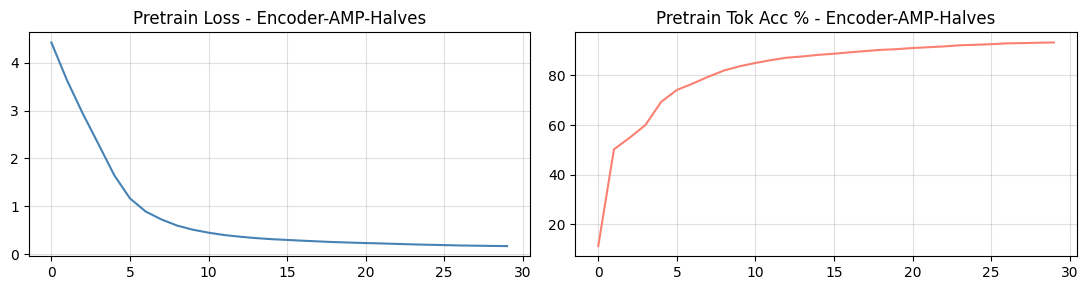

  Saved: ./ckpt/pretrained_encoder.pth
  Done. Final tok_acc: 93.3%

   2 — Decoder embed pretrain (sqamp H1 -> H2)

  [Decoder-SQAMP-Halves] halves=534  epochs=30  batch=4
    ep   1/30  loss=3.6602  tok_acc=7.6%
    ep   5/30  loss=2.0163  tok_acc=55.9%
    ep  10/30  loss=0.9374  tok_acc=71.9%
    ep  15/30  loss=0.5864  tok_acc=77.6%
    ep  20/30  loss=0.4314  tok_acc=80.3%
    ep  25/30  loss=0.3297  tok_acc=82.4%
    ep  30/30  loss=0.2894  tok_acc=84.0%
  tgt_embed saved: ./ckpt/pretrained_tgt_embed.pth

Shared pretraining COMPLETE.


In [ ]:
print('=' * 6)
print('   1 — Encoder LM pretrain on amp halves (QED+QCD)')
print('=' * 6)

_tmp_enc_model = build_model('MAC', CFG)  # MAC used only for its encoder structure

run_lm_pretrain(
    encoder    = _tmp_enc_model.encoder,
    embed      = _tmp_enc_model.encoder.embed,
    vocab      = qed_src_vocab,
    token_series = all_amp_halves,
    vocab_size = CFG['src_vocab_size'],
    max_len    = CFG['half_max_len'],
    label      = 'Encoder-AMP-Halves',
    n_epochs   = CFG['pretrain_epochs'],
    batch_size = CFG['batch_size'],
    lr         = CFG['optimizer_lr'],
    grad_accum = CFG['grad_accum_steps'],
    save_path  = f'{CKPT_DIR}/pretrained_encoder.pth',
)

print('\n' + '=' * 10)
print('   2 — Decoder embed pretrain (sqamp H1 -> H2)')
print('=' * 10)

run_half_split_pretrain(
    df             = all_sq_df,
    vocab          = qed_tgt_vocab,
    max_len        = CFG['half_max_len'],
    label          = 'Decoder-SQAMP-Halves',
    vocab_size     = CFG['tgt_vocab_size'],
    n_epochs       = CFG['pretrain_epochs'],
    batch_size     = CFG['batch_size'],
    lr             = CFG['optimizer_lr'],
    grad_accum     = CFG['grad_accum_steps'],
    save_embed_path = f'{CKPT_DIR}/pretrained_tgt_embed.pth',
)

del _tmp_enc_model
print('\nShared pretraining COMPLETE.')
